# Data assimilation on the latent space

## Open datasets

In [1]:
import xarray as xr
import numpy as np

fname_obs = "data/20181224_1800_Meteosat-11_Etna_VPRoutput.nc"

prior = xr.open_dataset("output/ETNA2018/prior.nc")
obs = xr.open_dataset(fname_obs)

In [2]:
N_ens = prior.sizes['ens']
latent_dim = prior.sizes['latent_dim']
sqrt_Nm1 = np.sqrt(N_ens - 1)

## Get observations

In [3]:
valid = (
    (obs["plume_mask"].values > 0) &
    (obs["mass"].values > 0)
)

y_obs = obs["mass"].values[valid].astype(np.float64)
lat_obs = obs["latitude"].values[valid].astype(np.float64)
lon_obs = obs["longitude"].values[valid].astype(np.float64)

In [4]:
lat_points = xr.DataArray(lat_obs, dims="obs")
lon_points = xr.DataArray(lon_obs, dims="obs")

In [5]:
N_obs = len(y_obs)
N_obs

2678

## Get the prior ensemble

In [6]:
Z = prior["z"].values.astype(np.float64)
X = prior["samples"]

Y_xr = X.interp(
    lat=lat_points,
    lon=lon_points,
    method="linear"
)
Y = Y_xr.values.astype(np.float64)

print("Y shape:", Y.shape)

Y shape: (1000, 2678)


In [7]:
print("NaNs in Y:", np.isnan(Y).sum())

NaNs in Y: 0


## Compute anomalies

In [8]:
Z_mean = Z.mean(axis=0)
Y_mean = Y.mean(axis=0)

Z_anom = Z - Z_mean
Y_anom = Y - Y_mean

In [9]:
Z_anom.shape == (N_ens, latent_dim)

True

In [10]:
Y_anom.shape == (N_ens, N_obs)

True

## Covariances matrices

In [11]:
# Observation-error covariance

obs_error_fraction = 0.50
obs_error_std = obs_error_fraction * y_obs
obs_error_std[obs_error_std<0.1] = 0.1 # Apply a minimum error (satellite detection limit)
R_diag = obs_error_std**2

print("R_diag shape:", R_diag.shape)
print("error std range:", obs_error_std.min(), obs_error_std.max())
print("R diagonal range:", R_diag.min(), R_diag.max())

R_diag shape: (2678,)
error std range: 0.1 1.02644674054899
R diagonal range: 0.010000000000000002 1.0535929111836457


In [12]:
# Ensemble anomaly of an observation, normalized by its observation uncertainty:
sigma_R = np.sqrt(R_diag)
A = Y_anom / sqrt_Nm1
A_tilde = A / sigma_R[None, :]

In [13]:
# Ensemble-space matrix:

C = np.eye(N_ens) + A_tilde @ A_tilde.T

In [14]:
print("condition number:", np.linalg.cond(C))

condition number: 797.4721507204813


## Innovations

In [15]:
innovation = y_obs - Y_mean

innovation_tilde = innovation / sigma_R

In [16]:
print("innovation shape:", innovation.shape)
print("innovation_tilde shape:", innovation_tilde.shape)

innovation shape: (2678,)
innovation_tilde shape: (2678,)


In [17]:
print("innovation_tilde mean:", innovation_tilde.mean())
print("innovation_tilde std:", innovation_tilde.std())
print("innovation_tilde min:", innovation_tilde.min())
print("innovation_tilde max:", innovation_tilde.max())

innovation_tilde mean: 1.1275951647385598
innovation_tilde std: 0.7050642233026592
innovation_tilde min: -0.7445477142012699
innovation_tilde max: 1.9947271846508696


## Solve the ensemble-space system

In [18]:
rhs = A_tilde @ innovation_tilde

print("rhs shape:", rhs.shape)
print("rhs mean:", rhs.mean())
print("rhs std:", rhs.std())

rhs shape: (1000,)
rhs mean: 5.684341886080802e-17
rhs std: 12.052421569406597


In [19]:
w = np.linalg.solve(C, rhs)

print("w shape:", w.shape)
print("w mean:", w.mean())
print("w std:", w.std())
print("w min:", w.min())
print("w max:", w.max())

w shape: (1000,)
w mean: 2.842170943040401e-17
w std: 0.7063020338969129
w min: -2.53198578978697
w max: 3.8258155034264654


## Analysis mean in latent space

In [20]:
Z_mean_analysis = ( Z_mean + Z_anom.T @ w / np.sqrt(N_ens - 1) )

In [21]:
print("Z_mean prior:   ", Z_mean)
print("Z_mean analysis:", Z_mean_analysis)

Z_mean prior:    [ 0.04965924  0.03190139  0.12972288  0.01153418 -0.03587266 -0.11464219
 -0.06576022 -0.02019229  0.01328799  0.0445874  -0.16426549 -0.02798393
  0.04512678 -0.10066323  0.0083063   0.02338765 -0.11503147  0.09342407
 -0.0370282  -0.09006049 -0.06506683 -0.10079644 -0.1418733  -0.06931672
  0.10159166  0.12407037 -0.03405511 -0.11334073  0.07907407 -0.2333351
 -0.21941531  0.0988004 ]
Z_mean analysis: [ 1.81133511  1.34937618 -0.51125882  0.08976345  0.12745466 -0.4116477
 -0.29321554  1.02683957 -2.22933774 -2.58950088  0.09132038  2.20745333
  0.151481    0.78093495 -0.69961087  1.81530078 -2.46486055  0.95827321
 -1.13505139  0.28405786 -3.52575021  0.95569429 -0.03155741  0.02653267
  1.68222712  0.8199899   1.42691774  0.95652178 -0.18374489 -0.6334596
  1.64512285  1.62304011]


## ETKF transform matrix

In [22]:
eigvals, eigvecs = np.linalg.eigh(C)

print("eigenvalue range:", eigvals.min(), eigvals.max())

eigenvalue range: 1.000000000000001 797.4721507204821


In [23]:
T = (
    eigvecs
    @ np.diag(1.0 / np.sqrt(eigvals))
    @ eigvecs.T
)

In [24]:
check = T @ C @ T.T

print(
    "T C T.T error:",
    np.max(np.abs(check - np.eye(N_ens)))
)

T C T.T error: 8.626432901337466e-14


In [25]:
Z_anom_analysis = T @ Z_anom
Z_analysis = Z_mean_analysis + Z_anom_analysis

## Summary

In [26]:
Pz_prior = np.cov(Z, rowvar=False)
Pz_analysis = np.cov(Z_analysis, rowvar=False)

In [28]:
variance_prior = np.trace(Pz_prior)
variance_analysis = np.trace(Pz_analysis)

print("Total prior variance:   ", variance_prior)
print("Total analysis variance:", variance_analysis)
print(
    "Variance ratio:",
    variance_analysis / variance_prior
)

Total prior variance:    31.02693731655024
Total analysis variance: 22.559951210056894
Variance ratio: 0.727108543775704


In [29]:
eig_prior = np.linalg.eigvalsh(Pz_prior)
eig_analysis = np.linalg.eigvalsh(Pz_analysis)

print("Smallest prior eigenvalue:   ", eig_prior.min())
print("Smallest analysis eigenvalue:", eig_analysis.min())

Smallest prior eigenvalue:    0.2644566820846975
Smallest analysis eigenvalue: 0.12407037913384189


## Store posterior

In [30]:
posterior_latent = xr.Dataset(
    data_vars={
        "z": (
            ("ens", "latent_dim"),
            Z_analysis.astype(np.float32)
        ),
        "z_mean": (
            ("latent_dim",),
            Z_mean_analysis.astype(np.float32)
        ),
    },
    coords={
        "ens": np.arange(N_ens),
        "latent_dim": np.arange(latent_dim),
    },
)

posterior_latent.to_netcdf("output/ETNA2018/posterior-latent.nc")

## Visualization

In [31]:
N = 6

rng = np.random.default_rng(42)

dims = rng.permutation(latent_dim)[:2*N]

pairs = [
    (dims[2*k], dims[2*k + 1])
    for k in range(N)
]

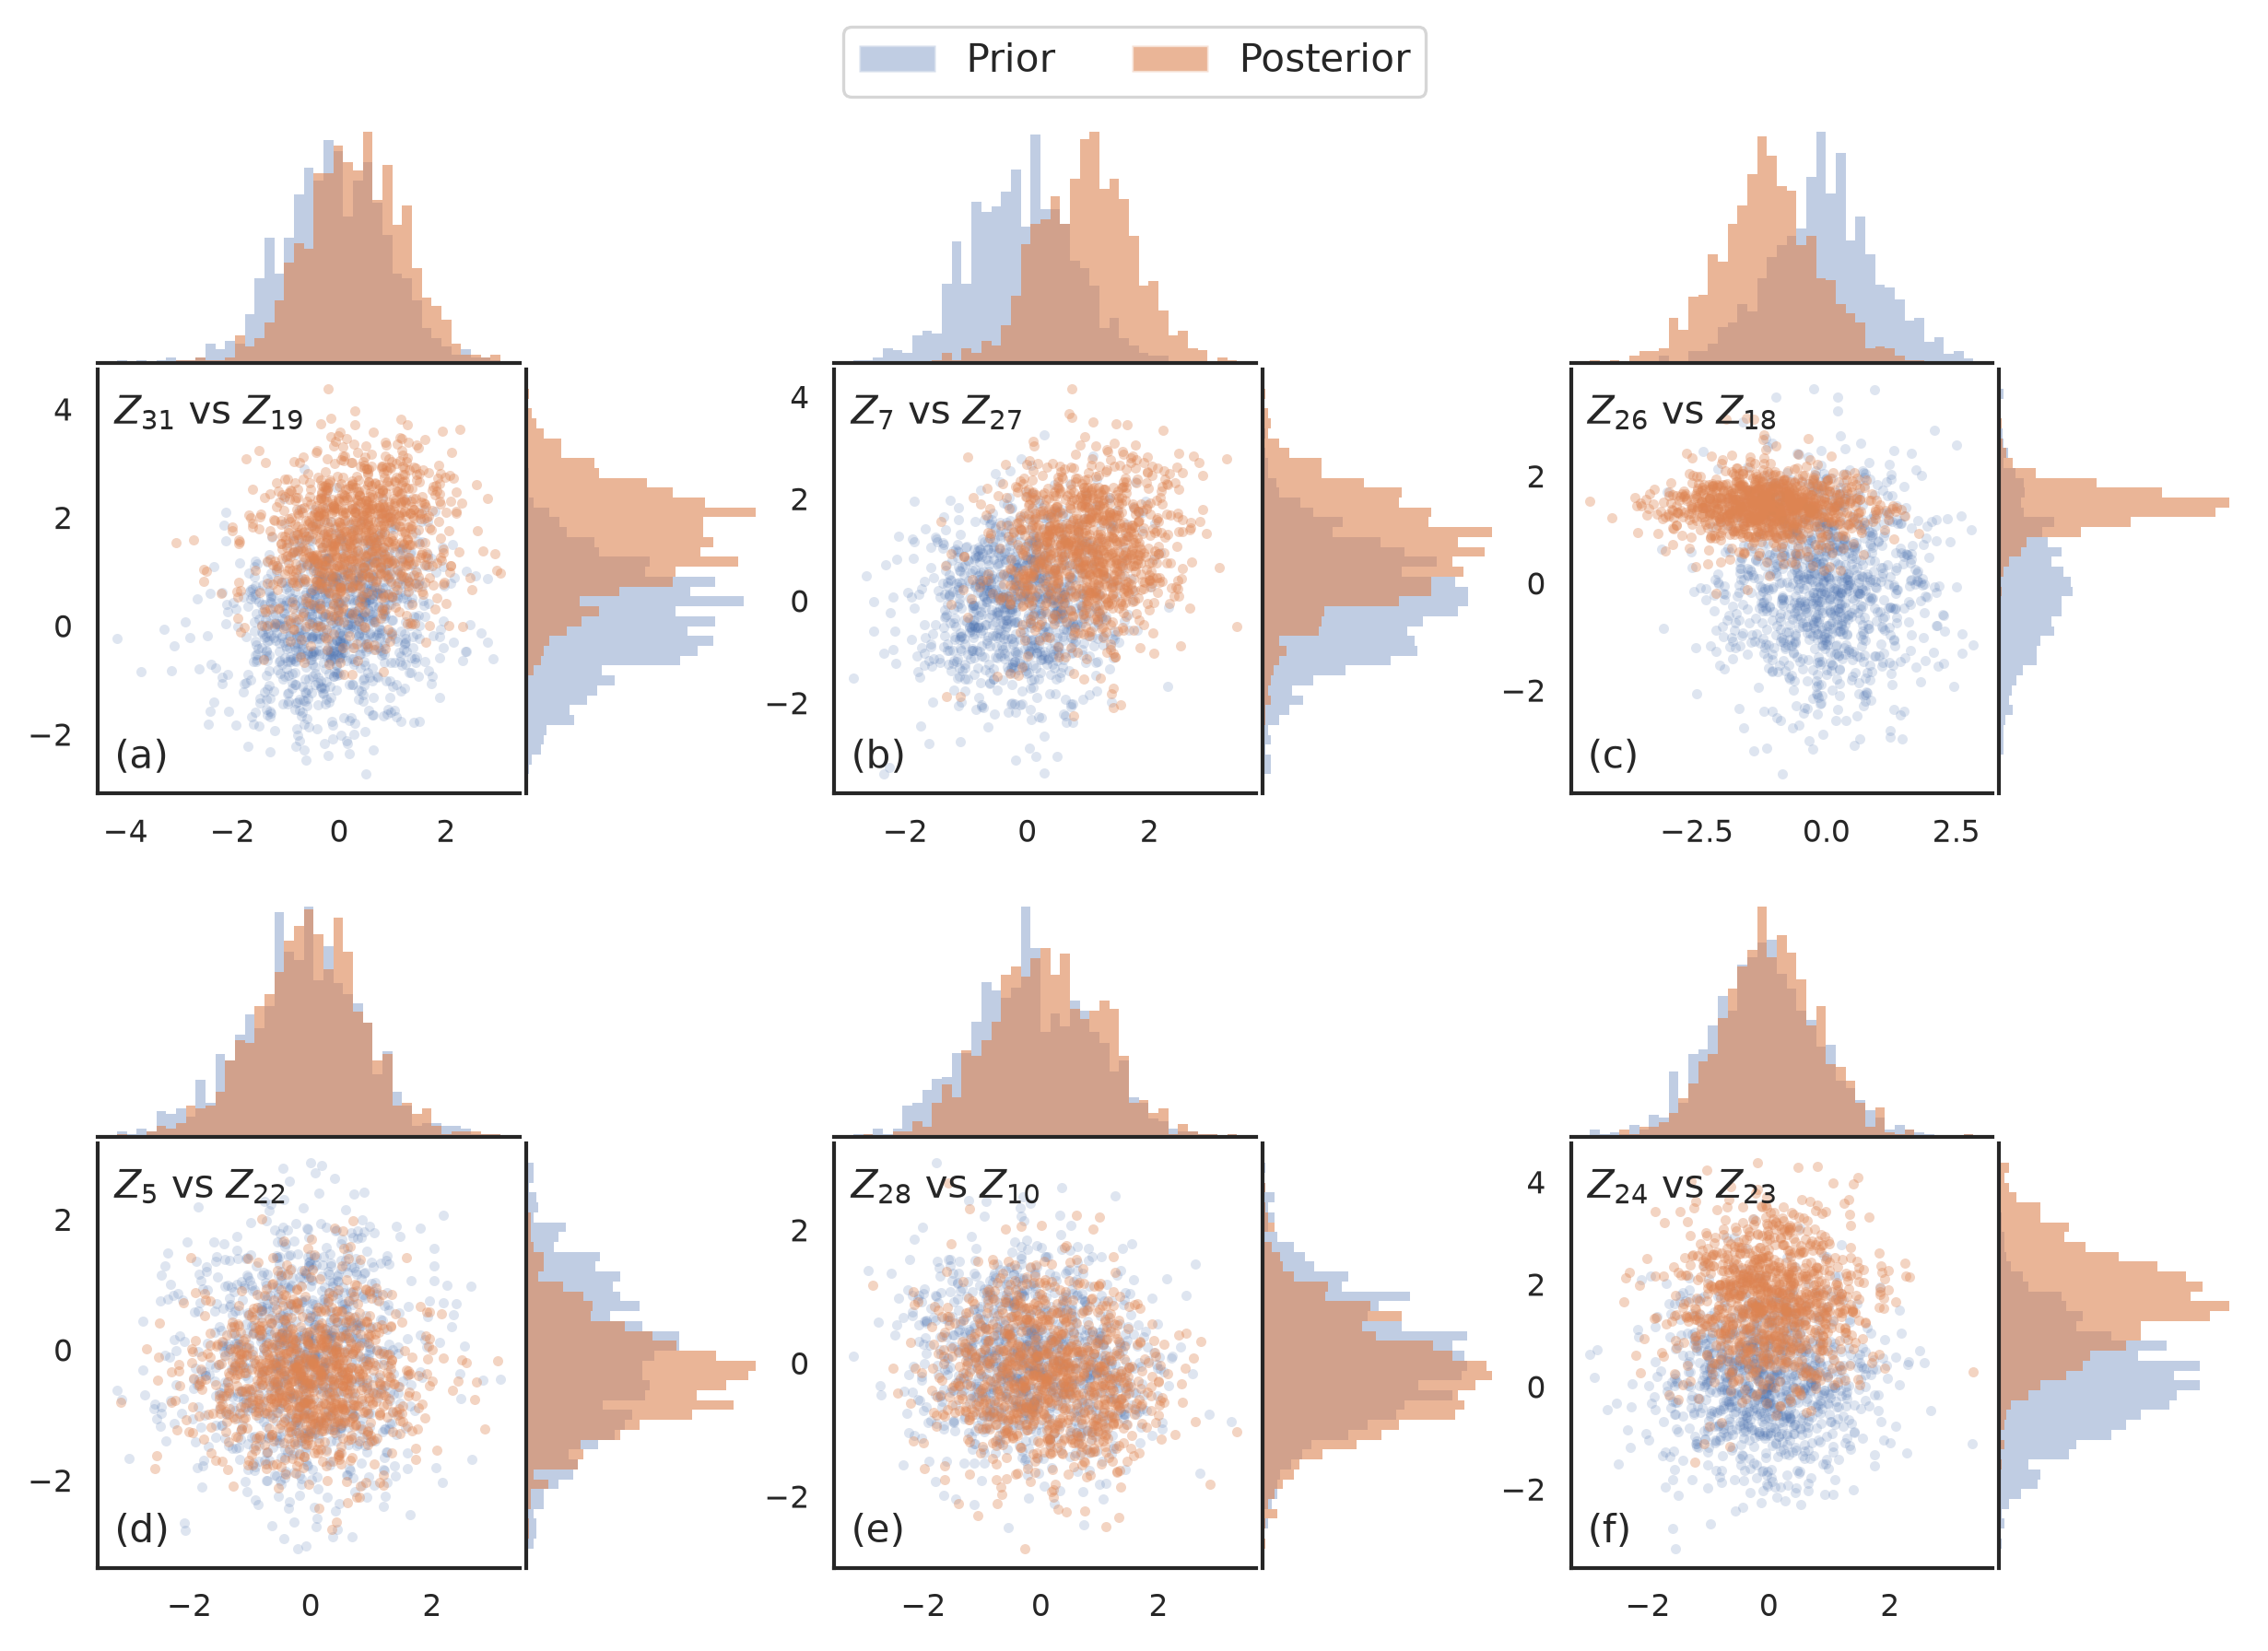

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# ------------------------------------------------------------
# Publication settings
# ------------------------------------------------------------

sns.set_theme(
    style="white",
    context="paper",
)

fig = plt.figure(
    figsize=(10, 6.8),
    dpi=300,
)

outer = fig.add_gridspec(
    2, 3,
    wspace=0.10,
    hspace=0.15,
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for k, (i, j) in enumerate(pairs):

    row = k // 3
    col = k % 3

    inner = outer[row, col].subgridspec(
        2, 2,

        # Bigger marginals
        width_ratios=[3.5, 2.0],
        height_ratios=[2.0, 3.5],

        wspace=0.02,
        hspace=0.02,
    )

    ax = fig.add_subplot(inner[1, 0])

    ax_top = fig.add_subplot(
        inner[0, 0],
        sharex=ax,
    )

    ax_right = fig.add_subplot(
        inner[1, 1],
        sharey=ax,
    )

    # --------------------------------------------------------
    # Main scatter
    # --------------------------------------------------------

    ax.scatter(
        Z[:, j],
        Z[:, i],
        s=7,
        alpha=0.18,
        linewidth=0,
        label="Prior",
    )

    ax.scatter(
        Z_analysis[:, j],
        Z_analysis[:, i],
        s=7,
        alpha=0.35,
        linewidth=0,
        label="Posterior",
    )

    # --------------------------------------------------------
    # Common histogram ranges
    # --------------------------------------------------------

    x_all = np.concatenate([
        Z[:, j],
        Z_analysis[:, j],
    ])

    y_all = np.concatenate([
        Z[:, i],
        Z_analysis[:, i],
    ])

    x_bins = np.linspace(
        x_all.min(),
        x_all.max(),
        40,
    )

    y_bins = np.linspace(
        y_all.min(),
        y_all.max(),
        40,
    )

    # --------------------------------------------------------
    # Top histogram
    # --------------------------------------------------------

    ax_top.hist(
        Z[:, j],
        bins=x_bins,
        density=True,
        alpha=0.35,
        linewidth=0,
    )

    ax_top.hist(
        Z_analysis[:, j],
        bins=x_bins,
        density=True,
        alpha=0.60,
        linewidth=0,
    )

    # --------------------------------------------------------
    # Right histogram
    # --------------------------------------------------------

    ax_right.hist(
        Z[:, i],
        bins=y_bins,
        density=True,
        orientation="horizontal",
        alpha=0.35,
        linewidth=0,
    )

    ax_right.hist(
        Z_analysis[:, i],
        bins=y_bins,
        density=True,
        orientation="horizontal",
        alpha=0.60,
        linewidth=0,
    )

    # --------------------------------------------------------
    # Remove histogram axes
    # --------------------------------------------------------

    ax_top.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False,
    )

    ax_right.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False,
    )

    ax_top.set_ylabel("")
    ax_top.set_xlabel("")

    ax_right.set_ylabel("")
    ax_right.set_xlabel("")

    # --------------------------------------------------------
    # Main axes
    # --------------------------------------------------------

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(
        labelsize=8,
        direction="out",
        length=3,
    )

    # --------------------------------------------------------
    # Pair label
    # --------------------------------------------------------

    ax.text(
        0.04,
        0.94,
        rf"$Z_{{{i}}}$ vs $Z_{{{j}}}$",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
    )

    # --------------------------------------------------------
    # Panel label
    # --------------------------------------------------------

    ax.text(
        0.04,
        0.06,
        f"({chr(97 + k)})",
        transform=ax.transAxes,
        fontsize=10,
        #fontweight="bold",
    )

    # --------------------------------------------------------
    # Clean spines
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_visible(False)

    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)
    ax_right.spines["bottom"].set_visible(False)

# Legend
legend_handles = [
    Patch(
        facecolor=plt.rcParams["axes.prop_cycle"].by_key()["color"][0],
        alpha=0.35,
        label="Prior",
    ),
    Patch(
        facecolor=plt.rcParams["axes.prop_cycle"].by_key()["color"][1],
        alpha=0.60,
        label="Posterior",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    frameon=True,
    fontsize=10,
)